2- MONK's datasets

In [3]:
import dtree as d
from tabulate import tabulate
import pandas as pd
import monkdata as m
from python.dtree import averageGain

print("MONK-1 train samples:", len(m.monk1))
print("MONK-2 train samples:", len(m.monk2))
print("MONK-3 train samples:", len(m.monk3))
print("MONK-1 test samples:", len(m.monk1test))
print("MONK-2 test samples:", len(m.monk2test))
print("MONK-3 test samples:", len(m.monk3test))
sample = m.monk1[0]
print("Attributes:", [attr.name for attr in sample.attribute])
print("Attribute values:", [attr.values for attr in sample.attribute])


MONK-1 train samples: 124
MONK-2 train samples: 169
MONK-3 train samples: 122
MONK-1 test samples: 432
MONK-2 test samples: 432
MONK-3 test samples: 432
Attributes: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6']
Attribute values: [(1, 2, 3), (1, 2, 3), (1, 2), (1, 2, 3), (1, 2, 3, 4), (1, 2)]


Assignment 0: Each one of the datasets has properties which makes them hard to learn. Motivate which of the three problems is most
difficult for a decision tree algorithm to learn?

MONk-1: (a_1 = a_2) or (a_5 = 1). Dataset isn't very difficult to learn, they are relatively simple and can be captured with a small decision tree. Because it only involves one equality condition and one attribute check, a decision tree can easily split on a_5 first, then handle a_1 = a_2 condition.

MONK-2: a_i = 1 for exacly two "i" elements in {1,2,...,6}. This is most difficult for a decision tree to learn, because it requires counting two attributes. Decision trees don't capture such global contraints well, so the resulting tree becomes very large and prone to overfitting.

MONK-3: (a_5 = 1 and a_4 = 1) or (a_5 != 4 and a_2 != 3). it has 5% additional noise in the training set. The added noise means that no decision tree can find perfect accuracy on the training set. This makes the classification problem most difficult(hard), because the tree may try to overfit to noise and leading to worse generalization.



3 Entropy
Assignment 1: The file dtree.py defines a function entropy which
calculates the entropy of a dataset. Import this file along with the
monks datasets and use it to calculate the entropy of the training
datasets.

In [4]:

E_monk_1 = d.entropy(m.monk1)
E_monk_2 = d.entropy(m.monk2)
E_monk_3 = d.entropy(m.monk3)
#print("MONK-1:", E_monk_1 )
#print("MONK-2:" ,E_monk_2)
#print("MONK-3:", E_monk_3)
data_1 = {
    "Dataset": ["MONK-1", "MONK-2", "MONK-3"],
    "Entropy": [E_monk_1, E_monk_2, E_monk_3]
}
print(tabulate(data_1, headers="keys", tablefmt="grid"))



+-----------+-----------+
| Dataset   |   Entropy |
+===========+===========+
| MONK-1    |  1        |
+-----------+-----------+
| MONK-2    |  0.957117 |
+-----------+-----------+
| MONK-3    |  0.999806 |
+-----------+-----------+


Assigment 1: Entropy 1 means the subsets is maximally impure, because the decision tree gains no information from splitting there.

And Entropy 0 means the dataset is more pure (better), because the decision tree can classify those examples with no uncertainty.

Thus, all three datasets start with very high uncertainty and worst starting point for classification,

Assignment 2: Explain entropy for a uniform distribution and a non-uniform distribution, present some example distributions with high and low entropy?

Entropy is a measure of uncertainty (unpredictability), or randomness in a dataset. with high entropy indicating more randomness and difficulty in making predictions, while low entropy signifies greater order and predictability.

Uniform distribution(high entropy):
A dataset where all outcomes are equally likely. This gives maximum entropy and it means the dataset is highly mixed and unpredictable
EX: if P_0 = 0.5 and P_1 = 0.5, Entropy = -0.5*log2(0.5) - 0.5*log2(0.5) = 1 bit. This represents maximum uncertainty.

Non-uniform distribution(low entropy):
A dataset with low entropy is very pure, and dominated by one class. since the outcome is more predictable.
EX: if P_0 = 0.9 and P_1 = 0.1, Entropy = -0.9*log2(0.9) - 0.1*log2(0.1) ≈ 0.46899 ≈ 0.47 bits. This indicates lower uncertainty.


4 Information Gain
,,Assignment 3:

In [5]:

#for i in range(6):
    #gain = averageGain(m.monk1, m.attributes[i])
    #print(f"Average Gain for attribute {i} in MONK-1: {gain}")

#for i in range(6):
    #gain = averageGain(m.monk2, m.attributes[i])
    #print(f"Average Gain for attribute {i} in MONK-2: {gain}")

#for i in range(6):
    #gain = averageGain(m.monk3, m.attributes[i])
    #print(f"Average Gain for attribute {i} in MONK-3: {gain}")

print("                    ###### Information Gain ######")
data_2 = {
    "Dataset": ["MONK-1", "MONK-2", "MONK-3"],
}
for i in range(6):
    data_2[f"a_{i+1}"] = [
        averageGain(m.monk1, m.attributes[i]),
        averageGain(m.monk2, m.attributes[i]),
        averageGain(m.monk3, m.attributes[i])
    ]
dff = pd.DataFrame(data_2)
print(tabulate(dff, headers="keys", tablefmt="grid"))

#which attribute should be used for splitting the examples
#at the root node?

grains_1 = []
for i, attr in enumerate(m.attributes):
    gain_1 = averageGain(m.monk1,attr)
    grains_1.append((i, attr.name, gain_1))

best_1 = max(grains_1, key=lambda x: x[2])
print(f"Best attribute for MONK-1 to splitting at root node: a_{best_1[0]+1} with gain {best_1[2]}")

grains_2 = []
for i, attr in enumerate(m.attributes):
    gain_2 = averageGain(m.monk2,attr)
    grains_2.append((i, attr.name, gain_2))
best_2 = max(grains_2, key=lambda x: x[2])
print(f"Best attribute for MONK-2 to splitting at root node: a_{best_2[0]+1} with gain {best_2[2]}")

grains_3 = []
for i, attr in enumerate(m.attributes):
    gain_3 = averageGain(m.monk3,attr)
    grains_3.append((i, attr.name, gain_3))
best_3 = max(grains_3, key=lambda x: x[2])
print(f"Best attribute for MONK-3 to splitting at root node: a_{best_3[0]+1} with gain {best_3[2]}")



                    ###### Information Gain ######
+----+-----------+------------+------------+-------------+------------+-----------+-------------+
|    | Dataset   |        a_1 |        a_2 |         a_3 |        a_4 |       a_5 |         a_6 |
+====+===========+============+============+=============+============+===========+=============+
|  0 | MONK-1    | 0.0752726  | 0.00583843 | 0.00470757  | 0.0263117  | 0.287031  | 0.000757856 |
+----+-----------+------------+------------+-------------+------------+-----------+-------------+
|  1 | MONK-2    | 0.00375618 | 0.0024585  | 0.00105615  | 0.0156642  | 0.0172772 | 0.00624762  |
+----+-----------+------------+------------+-------------+------------+-----------+-------------+
|  2 | MONK-3    | 0.00712087 | 0.293736   | 0.000831114 | 0.00289182 | 0.255912  | 0.00707703  |
+----+-----------+------------+------------+-------------+------------+-----------+-------------+
Best attribute for MONK-1 to splitting at root node: a_5 with gain 

Assigment 3: Based on the results, which attribute should be used for splitting the examples at the root node?

The information gain measures the expected reduction in impurity caused by partitioning the examples according to an attribute, because it best partition the dataset and leading to more pure, subsets and improved classification.
In dataset attribute with highest information gain should be used for splitting the examples at the root node:
MONK-1: a_5 = 0.287
MONK-2: a_5 = 0.0173
MONK-3: a_2 = 0.2937



Assignment 4:  Information Gain:
The information gain measures the expected reduction in impurity caused by
partitioning the examples according to an attribute. It thereby indicates the effectiveness of an attribute in classifying the training data. The information gain of an attribute A, relative to a collection of examples S is defined as.
where S_k is the subset of examples in S for the attribute A has the value k

In [6]:

def subset_entropies(dataset, attribute):
    entropies = []
    for v in attribute.values:
        subset = d.select(dataset, attribute, v)
        entropies.append((v, d.entropy(subset), len(subset)))
    return entropies

for dataset, name in [(m.monk1, "MONK-1"), (m.monk2, "MONK-2"), (m.monk3, "MONK-3")]:
    # find best attribute

    gains = [(averageGain(dataset,attr), attr) for attr in m.attributes]
    best_gain, best_attr = max(gains, key=lambda x: x[0])
    print(f"\n{name}: Best attribute is {best_attr.name} with gain {best_gain:.4f}")
    print("Subset entropies after splitting:")
    for v,e,n in subset_entropies(dataset, best_attr):
        print(f"  Value {v}: Entropy = {e:.4f}, Samples = {n}")
    print(f"Total entropy before splitting: {d.entropy(dataset):.4f}")



MONK-1: Best attribute is A5 with gain 0.2870
Subset entropies after splitting:
  Value 1: Entropy = 0.0000, Samples = 29
  Value 2: Entropy = 0.9383, Samples = 31
  Value 3: Entropy = 0.9481, Samples = 30
  Value 4: Entropy = 0.9082, Samples = 34
Total entropy before splitting: 1.0000

MONK-2: Best attribute is A5 with gain 0.0173
Subset entropies after splitting:
  Value 1: Entropy = 0.9103, Samples = 43
  Value 2: Entropy = 1.0000, Samples = 40
  Value 3: Entropy = 0.9633, Samples = 49
  Value 4: Entropy = 0.8780, Samples = 37
Total entropy before splitting: 0.9571

MONK-3: Best attribute is A2 with gain 0.2937
Subset entropies after splitting:
  Value 1: Entropy = 0.9183, Samples = 39
  Value 2: Entropy = 0.8296, Samples = 42
  Value 3: Entropy = 0.3776, Samples = 41
Total entropy before splitting: 0.9998


Assignment 4:
For splitting we choose the attribute that maximizes
the information gain, Eq.3. Looking at Eq.3 how does the entropy of
the subsets, S_k, look like when the information gain is maximized?

When the information gain is maximized, the second term must be as small as possible. This happens when the subsets S_k are pure or close to pure, it means their entropy is very low. and maximizing information gain corresponds to choosing a split where each subset contains examples that almost all belong to the same class.

How can we motivate using the information gain as a heuristic for
picking an attribute for splitting?

We use this because it directly measures the reduction in entropy after a split, it means the chosen attribute produces purer subsets accurate decision tree construction. since entropy reflects the level of class disorder, reducing it means the subsets are more homogeneous in terms of class labels, which makes classification easier.




Weighted average entropy = Entropy(S) - Gain(S, A):
MONK-1: WAE = 1.0 - 0.287 = 0.713, which is lower than the original entropy of 1.0 (significant reduction). a_5 produce one perfectly pure subset (value 1, E=0) and one mixed subset (value 2, E=0.918).

MONK-2: WAE = 0.9571 - 0.0173 = 0.9398, which is only slightly lower than the original entropy of 0.9571 (minimal reduction) and none of split produces very pure subsets, the split hardly reduces uncertainty.

MONK-3: WAE = 0.9998 - 0.2937 = 0.7061, which is a substantial reduction from the original entropy of 0.9998. a_2 produces one pure subset (value 3, E=0) and two mixed subsets (values 1 and 2, E=0.8113 and E=0.9183). (large gain)




5 Building Decision Trees

In [7]:
t_1 = d.buildTree(m.monk1, m.attributes)
#print("MONK-1 (E_train):",d.check(t_1, m.monk1))
#print("Monk-1 (E_test):",d.check(t_1, m.monk1test))

t_2 = d.buildTree(m.monk2, m.attributes)
#print("MONK-2 (E_train):",d.check(t_2, m.monk2))
#print("Monk-2 (E_test):",d.check(t_2, m.monk2test))

t_3 = d.buildTree(m.monk3, m.attributes)
#print("MONK-3 (E_train):",d.check(t_3, m.monk3))
#print("Monk-3 (E_test):", d.check(t_3, m.monk3test))


data_1["E_train"] = [1 - d.check(t_1, m.monk1),1 - d.check(t_2, m.monk2),1 - d.check(t_3, m.monk3)]
data_1["E_test"] = [1 - d.check(t_1, m.monk1test),1 - d.check(t_2, m.monk2test),1 - d.check(t_3, m.monk3test)]
if "Entropy" in data_1:
    del data_1["Entropy"]

dfff = pd.DataFrame(data_1)
print(tabulate(dfff, headers="keys", tablefmt="grid"))

# manual two-level tree for monk-1
best_attr = d.bestAttribute(m.monk1, m.attributes)
print(f"Root split on: {best_attr.name}")

for v in best_attr.values:
    subset = d.select(m.monk1, best_attr, v)
    next_best = d.bestAttribute(subset, [a for a in m.attributes if a != best_attr])
    print(f"  Node for {best_attr.name}={v} splits on: {next_best.name}")
    for vv in next_best.values:
        subsubset = d.select(subset, next_best, vv)
        maj = d.mostCommon(subsubset)
        print(f"    Leaf for {next_best.name}={vv}: Majority class = {'+' if maj else '-'}")

#Build full trees and evaluate
for i, (train, test, name) in enumerate([
    (m.monk1, m.monk1test, "MONK-1"),
    (m.monk2, m.monk2test, "MONK-2"),
    (m.monk3, m.monk3test, "MONK-3")
]):
    tree = d.buildTree(train, m.attributes)
    train_acc = d.check(tree, train)
    test_acc = d.check(tree, test)
    print(f"\n{name}:")
    print(f"  Train accuracy: {train_acc:.4f}")
    print(f"  Test accuracy:  {test_acc:.4f}")
    print(f"  Error train:    {1-train_acc:.4f}")
    print(f"  Error test:     {1-test_acc:.4f}")






+----+-----------+-----------+-----------+
|    | Dataset   |   E_train |    E_test |
+====+===========+===========+===========+
|  0 | MONK-1    |         0 | 0.171296  |
+----+-----------+-----------+-----------+
|  1 | MONK-2    |         0 | 0.30787   |
+----+-----------+-----------+-----------+
|  2 | MONK-3    |         0 | 0.0555556 |
+----+-----------+-----------+-----------+
Root split on: A5
  Node for A5=1 splits on: A1
    Leaf for A1=1: Majority class = +
    Leaf for A1=2: Majority class = +
    Leaf for A1=3: Majority class = +
  Node for A5=2 splits on: A4
    Leaf for A4=1: Majority class = -
    Leaf for A4=2: Majority class = -
    Leaf for A4=3: Majority class = -
  Node for A5=3 splits on: A6
    Leaf for A6=1: Majority class = -
    Leaf for A6=2: Majority class = -
  Node for A5=4 splits on: A1
    Leaf for A1=1: Majority class = -
    Leaf for A1=2: Majority class = -
    Leaf for A1=3: Majority class = +

MONK-1:
  Train accuracy: 1.0000
  Test accuracy:  0.828

assigment 5: Were your assumptions about the datasets correct? Explain the results you get for the training and test datasets?

my assumptions are correct because MONK-1 is moderately difficult. MONK-2 is the most difficult problem because of highest test error. and MONK-3 is easier than MONK-2 despite noise, since its underlying structure is simpler and more learnable.

For all three MONK datasets, the training error is 0, it means that the full decision trees fit the training data perfectly.

MONK-1: E_test= 0.17. the tree generalized reasonably well but not perfectly, showing some overfitting.

MONK-2: E_test = 0.31. This dataset is the hardest to learn, because the target concept exactly two attributes equal 1 from assigment 0 and is not easily and leading to poor generalization.

MONK-3: E_test = 0.056, it have too a noise in training data, and it's error is quite low, it means that the structure of the target function is still learnable and the noise does not overly harm generalization.

the train error of full tree always zero, because a full tree keeps splitting until every leaf is pure (all samples in a leaf are the same class), so it memorize the training set perfectly.


In [ ]:
import drawtree_qt5 as drawtree
# Visualize the trees

#drawtree.drawTree(t_1)
#drawtree.drawTree(t_2)
drawtree.drawTree(t_3)



6 Pruning

In [26]:
import monkdata as m
import dtree as d
import random

# Partition function (from lab handout)
def partition(data, fraction):
    ldata = list(data)
    #random.seed(42)
    random.shuffle(ldata)
    breakPoint = int(len(ldata) * fraction)
    return ldata[:breakPoint], ldata[breakPoint:]

# Reduced error pruning
def prune_tree(tree, validation):
    best_tree = tree
    best_perf = d.check(tree, validation)
    improved = True

    while improved:
        improved = False
        pruned_candidates = d.allPruned(best_tree)
        for candidate in pruned_candidates:
            perf = d.check(candidate, validation)
            if perf >= best_perf:   # keep if equal or better
                best_tree = candidate
                best_perf = perf
                improved = True
    return best_tree

# Run pruning experiment
def run_pruning_experiment(dataset, testset, fraction=0.6, name="Dataset"):
    # Split into training + validation
    train_part, val_part = partition(dataset, fraction)

    # Build full tree
    full_tree = d.buildTree(train_part, m.attributes)

    # Prune tree using validation set
    pruned_tree = prune_tree(full_tree, val_part)

    print(f"=== {name} ===")
    print("Validation accuracy (full tree):", d.check(full_tree, val_part))
    print("Validation accuracy (pruned tree):", d.check(pruned_tree, val_part))
    print("Test accuracy (full tree):", d.check(full_tree, testset))
    print("Test accuracy (pruned tree):", d.check(pruned_tree, testset))
    print("Test error (full tree):", 1 - d.check(full_tree, testset))
    print("Test error (pruned tree):", 1 - d.check(pruned_tree, testset))
    print()

# Run on MONK-1 and MONK-3
run_pruning_experiment(m.monk1, m.monk1test, fraction=0.6, name="MONK-1")
run_pruning_experiment(m.monk3, m.monk3test, fraction=0.6, name="MONK-3")


=== MONK-1 ===
Validation accuracy (full tree): 0.84
Validation accuracy (pruned tree): 0.88
Test accuracy (full tree): 0.8287037037037037
Test accuracy (pruned tree): 0.8055555555555556
Test error (full tree): 0.17129629629629628
Test error (pruned tree): 0.19444444444444442

=== MONK-3 ===
Validation accuracy (full tree): 0.8979591836734694
Validation accuracy (pruned tree): 0.9591836734693877
Test accuracy (full tree): 0.8796296296296297
Test accuracy (pruned tree): 0.9537037037037037
Test error (full tree): 0.12037037037037035
Test error (pruned tree): 0.04629629629629628



Assigment 6:
The idea of reduced error pruning is to consider each node in the tree as a candidate for removal. A node is removed if the resulting pruned tree performs at least as well as the original tree over a separate validation dataset, i.e. a dataset not used during training.
 When a node is removed, the subtree rooted at that node is replaced by a leaf node, to which the majority classification of examples in that node is assigned. For the purpose of pruning, we have to split our original training data into one training set for building the tree and one validation set for pruning.

pruning Algorithm:
split training data into a smaller training set and a validation set. for each node try removing it's subtree and replace with a leaf. (majority class). if this replacement doesn't reduce accuracy on the validation set, keep the pruning, otherwise, keep the original subtree

From a bias variance Trade-off perspective, for full trees are overfit with low bias but high variance and for pruned trees are better balance with slightly higher bias but significantly lower variance (better generalization).

TOo much pruning -> tree to simple -> high bias (underfitting)
to little pruning -> tree to complex -> high variance (overfitting).

assigment 7

MONK-1 fraction=0.3: mean=0.2331, std=0.0377
MONK-1 fraction=0.4: mean=0.2147, std=0.0400
MONK-1 fraction=0.5: mean=0.2010, std=0.0412
MONK-1 fraction=0.6: mean=0.1968, std=0.0423
MONK-1 fraction=0.7: mean=0.2016, std=0.0409
MONK-1 fraction=0.8: mean=0.2194, std=0.0386
#########################################
MONK-3 fraction=0.3: mean=0.0844, std=0.0559
MONK-3 fraction=0.4: mean=0.0573, std=0.0442
MONK-3 fraction=0.5: mean=0.0453, std=0.0373
MONK-3 fraction=0.6: mean=0.0337, std=0.0286
MONK-3 fraction=0.7: mean=0.0328, std=0.0274
MONK-3 fraction=0.8: mean=0.0375, std=0.0314


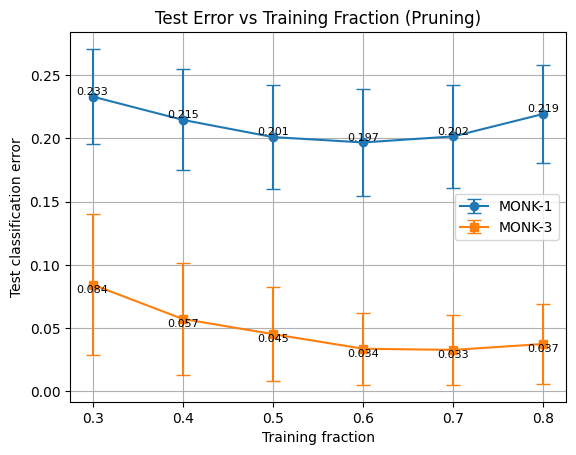

In [37]:
import numpy as np
import matplotlib.pyplot as plt

fractions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
n_runs = 100

def evaluate_pruning(dataset, testset, name):
    means = []
    stds = []
    for frac in fractions:
        errors = []
        for _ in range(n_runs):
            train, val = partition(dataset, frac)
            tree = d.buildTree(train, m.attributes)
            pruned_tree = prune_tree(tree, val)
            test_error = 1 - d.check(pruned_tree, testset)
            errors.append(test_error)
        means.append(np.mean(errors))
        stds.append(np.std(errors))
        print(f"{name} fraction={frac}: mean={means[-1]:.4f}, std={stds[-1]:.4f}")
    return means, stds

mean1, std1 = evaluate_pruning(m.monk1, m.monk1test, "MONK-1")
print("#########################################")
mean3, std3 = evaluate_pruning(m.monk3, m.monk3test, "MONK-3")

plt.errorbar(fractions, mean1, yerr=std1, label="MONK-1", marker='o', capsize=5)
plt.errorbar(fractions, mean3, yerr=std3, label="MONK-3", marker='s', capsize=5)
plt.xlabel("Training fraction")
plt.ylabel("Test classification error")
plt.title("Test Error vs Training Fraction (Pruning)")
plt.legend()
plt.grid(True)
for i, frac in enumerate(fractions):
    plt.text(frac, mean1[i], f"{mean1[i]:.3f}", ha='center', va='bottom', fontsize=8)
    plt.text(frac, mean3[i], f"{mean3[i]:.3f}", ha='center', va='top', fontsize=8)
plt.show()





MONK-1:
Test error decreases when moving from 0.3 to 0.6 fraction, reaching a minimum at 0.6 (0.197 = 19.7%), then rises slightly. This shows the expected Trade-off: too little validation data (fraction near 0.8) makes pruning less effective, while too little training data (fraction near 0.3) weakens the model.

MONK-3:
Test error reduces from 0.3 to 0.7, reaching its best at fractions 0.6-0.7 (0.33 and 0.32). This matches the fact that MONK-3 contains 5% noise and pruning removes branches that overfit to noisy examples, improving generalization significantly.


Monk-3 contains noise, so full tree overfits to it. pruning remove unnecessary branches and reduces overfitting.
Monk-1 has no noise, so the full tree already generalization well, and pruning can make it worse.

In [39]:
datasets = {
    "MONK-1": (m.monk1, m.monk1test, mean1),
    "MONK-3": (m.monk3, m.monk3test, mean3),
}

print("\nFinal Results Summary:")
print(f"{'Dataset':<8} | {'Best fraction':<13} | {'Best mean E_test (pruned)':<28} | {'E_test (full tree)':<15}")
print("-" * 75)

for name, (trainset, testset, means) in datasets.items():
    full_tree = d.buildTree(trainset, m.attributes)
    full_error = 1 - d.check(full_tree, testset)
    best_idx = int(np.argmin(means))
    best_frac = fractions[best_idx]
    best_err = means[best_idx]
    print(f"{name:<8} | {best_frac:<13.1f} | {best_err:<28.4f} | {full_error:<15.4f}")


Final Results Summary:
Dataset  | Best fraction | Best mean E_test (pruned)    | E_test (full tree)
---------------------------------------------------------------------------
MONK-1   | 0.6           | 0.1968                       | 0.1713         
MONK-3   | 0.7           | 0.0328                       | 0.0556         
